# Blatt 9

## Aufgabe 1a


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)


/Users/giulien/Developer/ML-Datenanalyse/Giulien/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [15]:
df_raw = pd.read_csv('pvtest.csv')
time_index = pd.to_datetime(df_raw['Time'], format='%d.%m.%y %H:%M')
df_raw['hour'] = time_index.dt.hour + time_index.dt.minute / 60.0

features = ['Edaily', 'Dci', 'Dcp', 'Dcu', 'Temp1', 'hour']
ts_df = df_raw[features].copy()
ts_df.index = time_index

ts_df.head()


,Edaily,Dci,Dcp,Dcu,Temp1,hour
Time,,,,,,
2021-01-20 07:45:00,0.0,0.0,0,0,0.0,7.750000
2021-01-20 07:50:00,0.0,0.0,0,0,0.0,7.833333
2021-01-20 07:55:00,0.0,0.0,0,0,0.0,7.916667
2021-01-20 08:00:00,0.0,0.0,0,0,0.0,8.000000
2021-01-20 08:05:00,0.0,0.0,0,0,0.0,8.083333


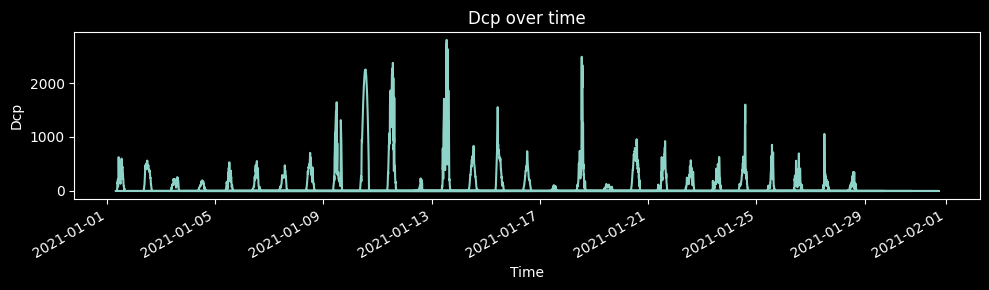

In [3]:
plt.figure(figsize=(10, 3))
ts_df['Dcp'].plot()
plt.title('Dcp over time')
plt.xlabel('Time')
plt.ylabel('Dcp')
plt.tight_layout()
plt.show()


## Aufgabe 1b


In [4]:
split_ratio = 0.8
split_idx = int(len(ts_df) * split_ratio)

train_df = ts_df.iloc[:split_idx]
test_df = ts_df.iloc[split_idx:]

print('Train:', train_df.index.min(), '->', train_df.index.max(), 'rows:', len(train_df))
print('Test :', test_df.index.min(), '->', test_df.index.max(), 'rows:', len(test_df))


Train: 2021-01-01 07:55:00 -> 2021-01-31 17:45:00 rows: 2836
Test : 2021-01-03 07:55:00 -> 2021-01-26 17:40:00 rows: 709


## Aufgabe 1c


In [5]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
test_scaled = scaler.transform(test_df.values)

window_size = 36  # 3 hours with 5-minute steps
horizon = 1       # 5 minutes ahead
target_col = features.index('Dcp')

def make_windows(data, window_size, horizon, target_col):
    X, y = [], []
    max_start = len(data) - window_size - horizon + 1
    for i in range(max_start):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1, target_col])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, window_size, horizon, target_col)
X_test, y_test = make_windows(test_scaled, window_size, horizon, target_col)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


X_train: (2800, 36, 6) y_train: (2800,)
X_test : (673, 36, 6) y_test : (673,)


## Aufgabe 1d


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, len(features))),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1),
])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 36, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

## Aufgabe 1e

In [7]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=5, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.3232 - mae: 0.3232 - val_loss: 0.0975 - val_mae: 0.0975 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2041 - mae: 0.2041 - val_loss: 0.0851 - val_mae: 0.0851 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1792 - mae: 0.1792 - val_loss: 0.0787 - val_mae: 0.0787 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1699 - mae: 0.1699 - val_loss: 0.0742 - val_mae: 0.0742 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1653 - mae: 0.1653 - val_loss: 0.0710 - val_mae: 0.0710 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1554 - mae: 0.1554 - val_loss: 0.0685 - val_mae: 0.0685 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1462 - mae: 0.1462 - val_loss: 0.0699 - val_mae: 0.0699 - learning_rate: 0.0010
Epoch 8/100


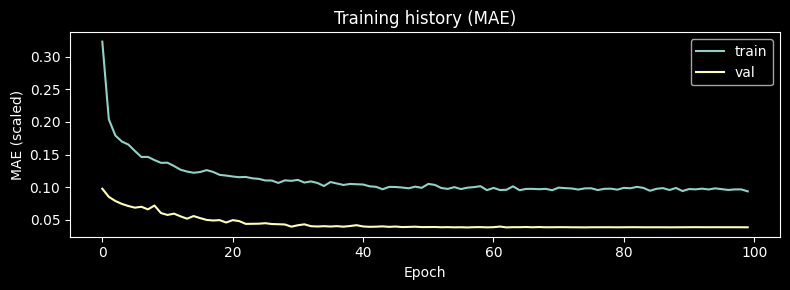

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('Training history (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE (scaled)')
plt.legend()
plt.tight_layout()
plt.show()


## Aufgabe 1f


In [9]:
pred_scaled = model.predict(X_test).reshape(-1)

scale = scaler.scale_[target_col]
mean = scaler.mean_[target_col]
y_pred = pred_scaled * scale + mean
y_true = y_test * scale + mean

mae = np.mean(np.abs(y_true - y_pred))
print(f'Test MAE (original units): {mae:.2f}')


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test MAE (original units): 38.22


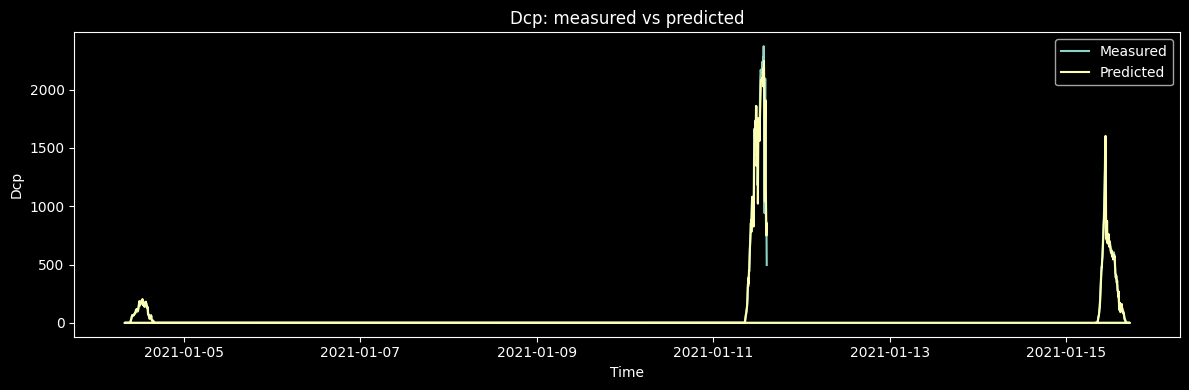

In [10]:
test_target_times = test_df.index[window_size + horizon - 1:]
plot_len = min(300, len(y_true))

plt.figure(figsize=(12, 4))
plt.plot(test_target_times[:plot_len], y_true[:plot_len], label='Measured')
plt.plot(test_target_times[:plot_len], y_pred[:plot_len], label='Predicted')
plt.title('Dcp: measured vs predicted')
plt.xlabel('Time')
plt.ylabel('Dcp')
plt.legend()
plt.tight_layout()
plt.show()
